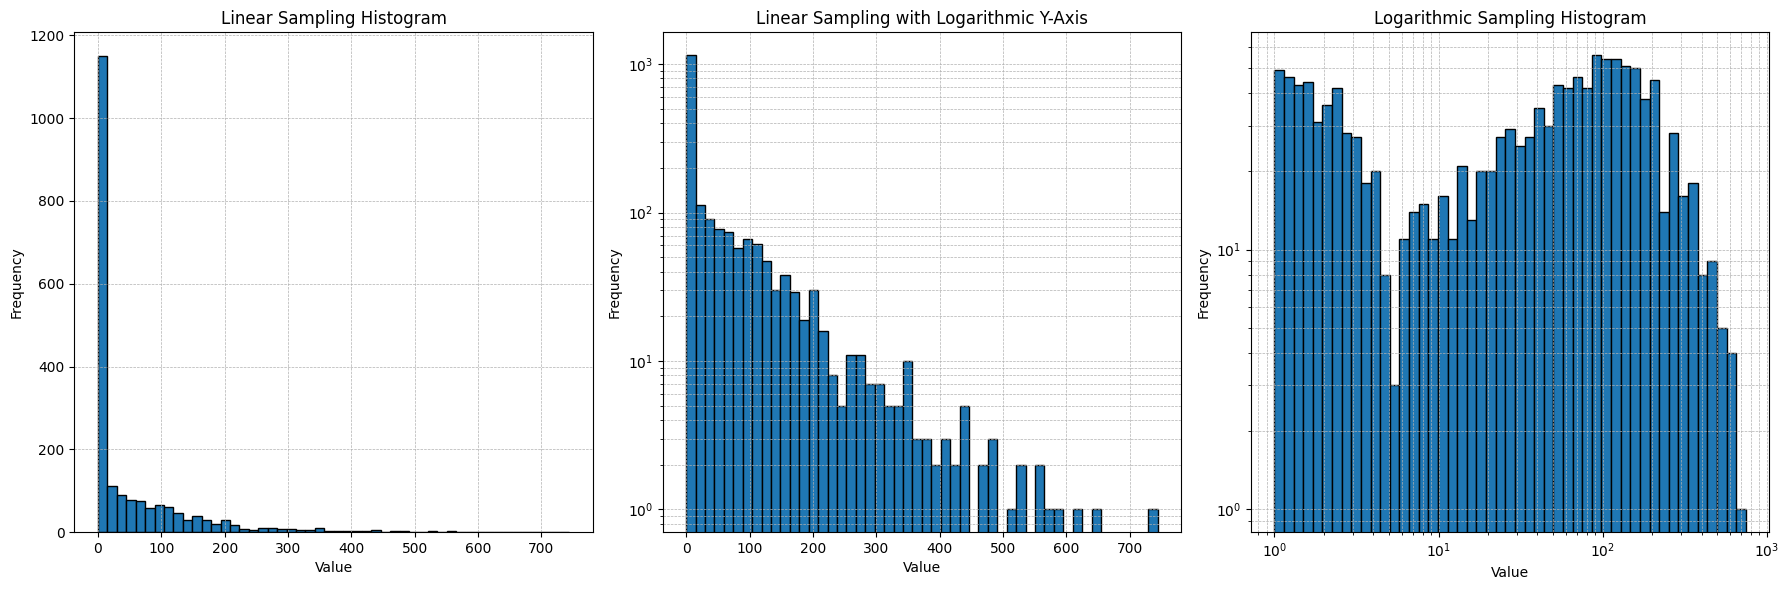

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate the dataset
np.random.seed(42)  # For reproducibility
data = np.concatenate([np.random.exponential(scale=1, size=1000),
                       np.random.exponential(scale=100, size=1000)])

# Plotting
plt.figure(figsize=(18, 6))

# 1. Linear Sampling Histogram
plt.subplot(1, 3, 1)
plt.hist(data, bins=50, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Linear Sampling Histogram')
plt.grid(True, linestyle='--', linewidth=0.5)

# 2. Linear Sampling with Logarithmic Axis
plt.subplot(1, 3, 2)
plt.hist(data, bins=50, edgecolor='black')
plt.yscale('log')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Linear Sampling with Logarithmic Y-Axis')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 3. Logarithmic Sampling Histogram
bins_log = np.logspace(0, np.log10(data.max()), 50)  # Logarithmic bin edges
plt.subplot(1, 3, 3)
plt.hist(data, bins=bins_log, edgecolor='black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Logarithmic Sampling Histogram')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


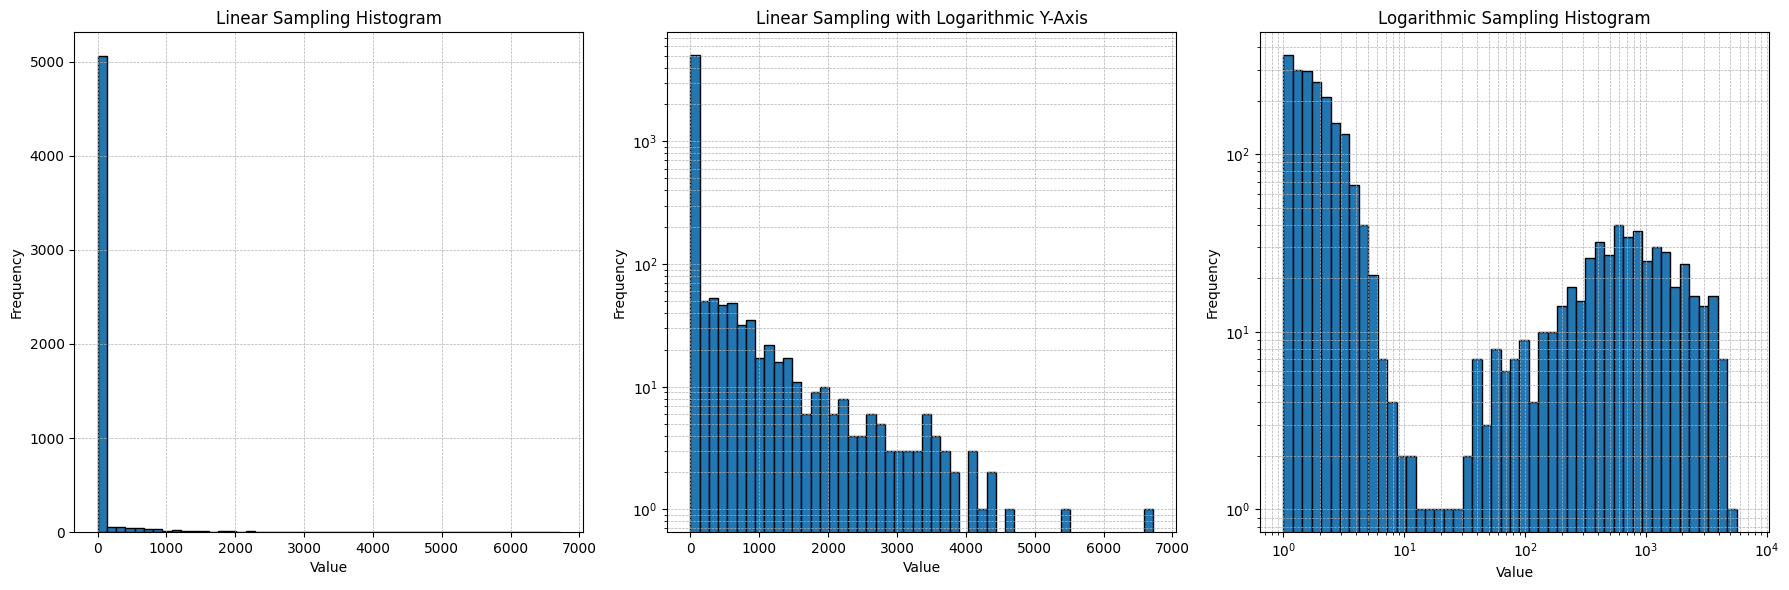

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Generate the bimodal dataset
np.random.seed(42)  # For reproducibility
low_intensity = np.random.exponential(scale=1, size=5000)
high_intensity = np.random.exponential(scale=1000, size=500)
data = np.concatenate([low_intensity, high_intensity])

# Plotting
plt.figure(figsize=(18, 6))

# 1. Linear Sampling Histogram
plt.subplot(1, 3, 1)
plt.hist(data, bins=50, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Linear Sampling Histogram')
plt.grid(True, linestyle='--', linewidth=0.5)

# 2. Linear Sampling with Logarithmic Axis
plt.subplot(1, 3, 2)
plt.hist(data, bins=50, edgecolor='black')
plt.yscale('log')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Linear Sampling with Logarithmic Y-Axis')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 3. Logarithmic Sampling Histogram
bins_log = np.logspace(0, np.log10(data.max()), 50)  # Logarithmic bin edges
plt.subplot(1, 3, 3)
plt.hist(data, bins=bins_log, edgecolor='black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Logarithmic Sampling Histogram')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()


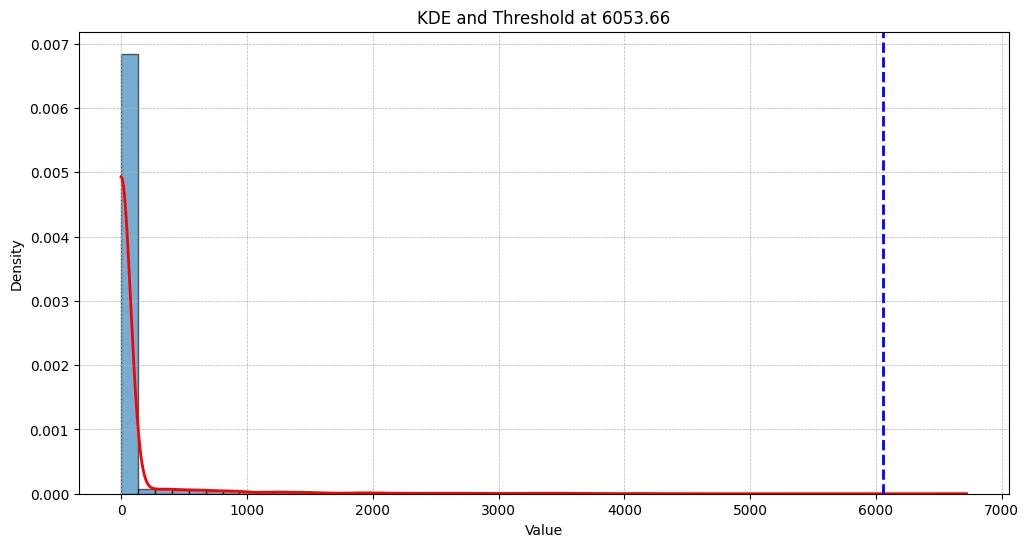

Threshold determined by KDE: 6053.66


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Generate the bimodal dataset
np.random.seed(42)
low_intensity = np.random.exponential(scale=1, size=5000)
high_intensity = np.random.exponential(scale=1000, size=500)
data = np.concatenate([low_intensity, high_intensity])

# Kernel Density Estimation
kde = gaussian_kde(data)
x = np.linspace(0, data.max(), 1000)
kde_values = kde(x)

# Find the local minimum between the two peaks
local_min_index = np.argmin(kde_values)
threshold_kde = x[local_min_index]

# Plot the KDE and threshold
plt.figure(figsize=(12, 6))
plt.hist(data, bins=50, density=True, edgecolor='black', alpha=0.6)
plt.plot(x, kde(x), color='red', lw=2)
plt.axvline(threshold_kde, color='blue', linestyle='--', lw=2)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title(f'KDE and Threshold at {threshold_kde:.2f}')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()

print(f"Threshold determined by KDE: {threshold_kde:.2f}")


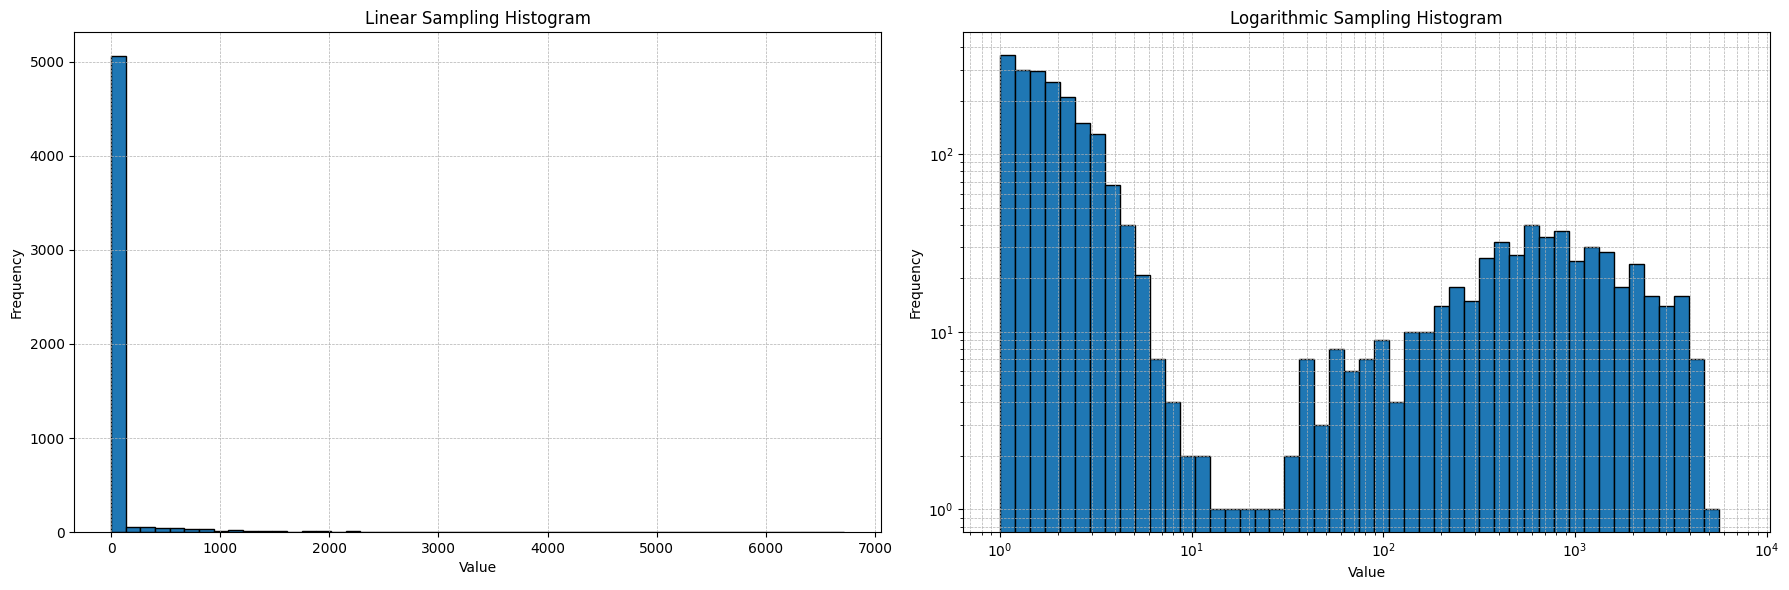

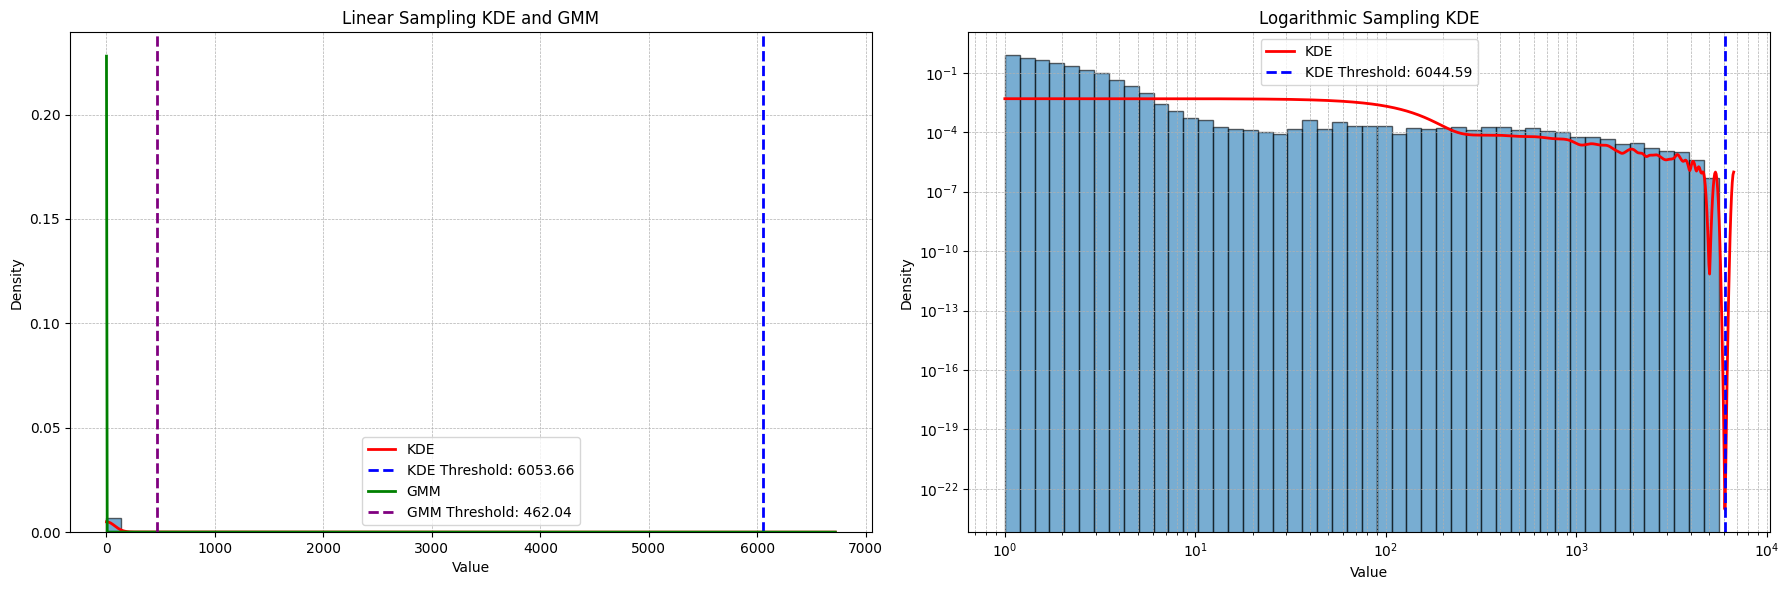

Threshold determined by KDE (Linear Sampling): 6053.66
Threshold determined by GMM (Linear Sampling): 462.04
Threshold determined by KDE (Logarithmic Sampling): 6044.59


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture

# Generate the bimodal dataset
np.random.seed(42)
low_intensity = np.random.exponential(scale=1, size=5000)
high_intensity = np.random.exponential(scale=1000, size=500)
data = np.concatenate([low_intensity, high_intensity])

# Plotting
plt.figure(figsize=(18, 6))

# Linear Sampling Histogram
plt.subplot(1, 2, 1)
plt.hist(data, bins=50, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Linear Sampling Histogram')
plt.grid(True, linestyle='--', linewidth=0.5)

# Logarithmic Sampling Histogram
bins_log = np.logspace(0, np.log10(data.max()), 50)  # Logarithmic bin edges
plt.subplot(1, 2, 2)
plt.hist(data, bins=bins_log, edgecolor='black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Logarithmic Sampling Histogram')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# KDE and GMM for Linear Sampling
kde = gaussian_kde(data)
x_linear = np.linspace(0, data.max(), 1000)
kde_values_linear = kde(x_linear)
local_min_index_linear = np.argmin(kde_values_linear)
threshold_kde_linear = x_linear[local_min_index_linear]

gmm_linear = GaussianMixture(n_components=2, random_state=42)
gmm_linear.fit(data.reshape(-1, 1))
means_linear = gmm_linear.means_.flatten()
threshold_gmm_linear = np.mean(means_linear)

# KDE and GMM for Logarithmic Sampling
x_log = np.logspace(0, np.log10(data.max()), 1000)
kde_values_log = kde(x_log)
local_min_index_log = np.argmin(kde_values_log)
threshold_kde_log = x_log[local_min_index_log]

# Plotting KDE and GMM results
plt.figure(figsize=(18, 6))

# Linear Sampling KDE and GMM
plt.subplot(1, 2, 1)
plt.hist(data, bins=50, density=True, edgecolor='black', alpha=0.6)
plt.plot(x_linear, kde_values_linear, color='red', lw=2, label='KDE')
plt.axvline(threshold_kde_linear, color='blue', linestyle='--', lw=2, label=f'KDE Threshold: {threshold_kde_linear:.2f}')
pdf_gmm_linear = np.exp(gmm_linear.score_samples(x_linear.reshape(-1, 1)))
plt.plot(x_linear, pdf_gmm_linear, color='green', lw=2, label='GMM')
plt.axvline(threshold_gmm_linear, color='purple', linestyle='--', lw=2, label=f'GMM Threshold: {threshold_gmm_linear:.2f}')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Linear Sampling KDE and GMM')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

# Logarithmic Sampling KDE
plt.subplot(1, 2, 2)
plt.hist(data, bins=bins_log, density=True, edgecolor='black', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.plot(x_log, kde_values_log, color='red', lw=2, label='KDE')
plt.axvline(threshold_kde_log, color='blue', linestyle='--', lw=2, label=f'KDE Threshold: {threshold_kde_log:.2f}')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Logarithmic Sampling KDE')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"Threshold determined by KDE (Linear Sampling): {threshold_kde_linear:.2f}")
print(f"Threshold determined by GMM (Linear Sampling): {threshold_gmm_linear:.2f}")
print(f"Threshold determined by KDE (Logarithmic Sampling): {threshold_kde_log:.2f}")


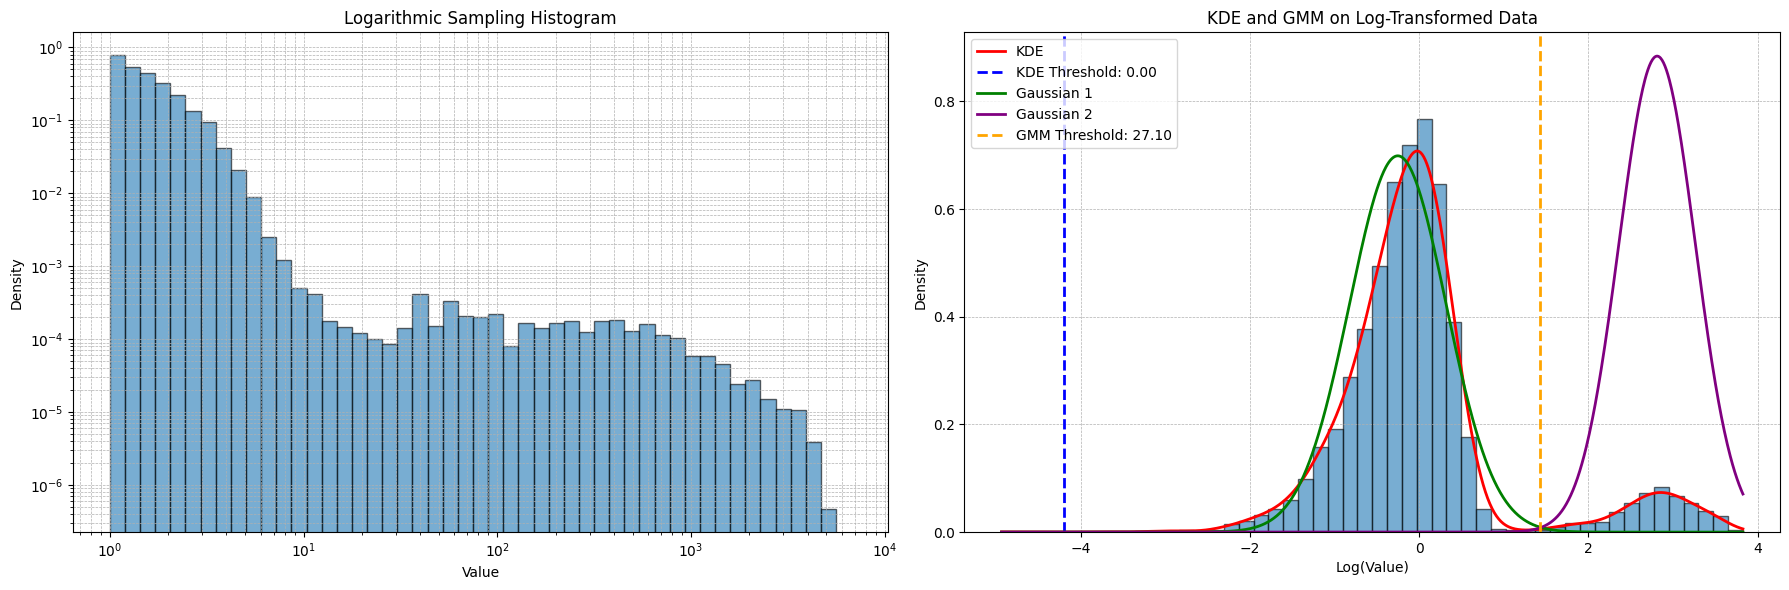

Threshold determined by KDE on log-transformed data: 0.00
Threshold determined by GMM on log-transformed data: 27.10


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture

# Generate the bimodal dataset
np.random.seed(42)
low_intensity = np.random.exponential(scale=1, size=5000)
high_intensity = np.random.exponential(scale=1000, size=500)
data = np.concatenate([low_intensity, high_intensity])

# Transform data to log scale
data_log = np.log10(data[data > 0])  # Avoid log(0) by excluding zero values

# KDE on log-transformed data
kde_log = gaussian_kde(data_log)
x_log_transformed = np.linspace(data_log.min(), data_log.max(), 1000)
kde_values_log_transformed = kde_log(x_log_transformed)
local_min_index_log_transformed = np.argmin(kde_values_log_transformed)
threshold_kde_log_transformed = x_log_transformed[local_min_index_log_transformed]
threshold_kde_log_original = 10**threshold_kde_log_transformed

# GMM on log-transformed data
gmm_log = GaussianMixture(n_components=2, random_state=42)
gmm_log.fit(data_log.reshape(-1, 1))
means_log = gmm_log.means_.flatten()
stds_log = np.sqrt(gmm_log.covariances_).flatten()

# Finding intersection point of the two Gaussians on log scale
def gaussian(x, mean, std):
    return (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

x_log_transformed_dense = np.linspace(data_log.min(), data_log.max(), 1000)
gaussian_1_log = gaussian(x_log_transformed_dense, means_log[0], stds_log[0])
gaussian_2_log = gaussian(x_log_transformed_dense, means_log[1], stds_log[1])
intersection_index_log = np.argwhere(np.diff(np.sign(gaussian_1_log - gaussian_2_log))).flatten()
threshold_gmm_log_transformed = x_log_transformed_dense[intersection_index_log][0]
threshold_gmm_log_original = 10**threshold_gmm_log_transformed

# Plotting results
plt.figure(figsize=(18, 6))

# Logarithmic Sampling Histogram with KDE and GMM on log-transformed data
bins_log = np.logspace(0, np.log10(data.max()), 50)
plt.subplot(1, 2, 1)
plt.hist(data, bins=bins_log, density=True, edgecolor='black', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Logarithmic Sampling Histogram')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# KDE and GMM on log-transformed data
plt.subplot(1, 2, 2)
plt.hist(data_log, bins=50, density=True, edgecolor='black', alpha=0.6)
plt.plot(x_log_transformed, kde_values_log_transformed, color='red', lw=2, label='KDE')
plt.axvline(threshold_kde_log_transformed, color='blue', linestyle='--', lw=2, label=f'KDE Threshold: {threshold_kde_log_original:.2f}')
plt.plot(x_log_transformed_dense, gaussian_1_log, color='green', lw=2, label='Gaussian 1')
plt.plot(x_log_transformed_dense, gaussian_2_log, color='purple', lw=2, label='Gaussian 2')
plt.axvline(threshold_gmm_log_transformed, color='orange', linestyle='--', lw=2, label=f'GMM Threshold: {threshold_gmm_log_original:.2f}')
plt.xlabel('Log(Value)')
plt.ylabel('Density')
plt.title('KDE and GMM on Log-Transformed Data')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"Threshold determined by KDE on log-transformed data: {threshold_kde_log_original:.2f}")
print(f"Threshold determined by GMM on log-transformed data: {threshold_gmm_log_original:.2f}")


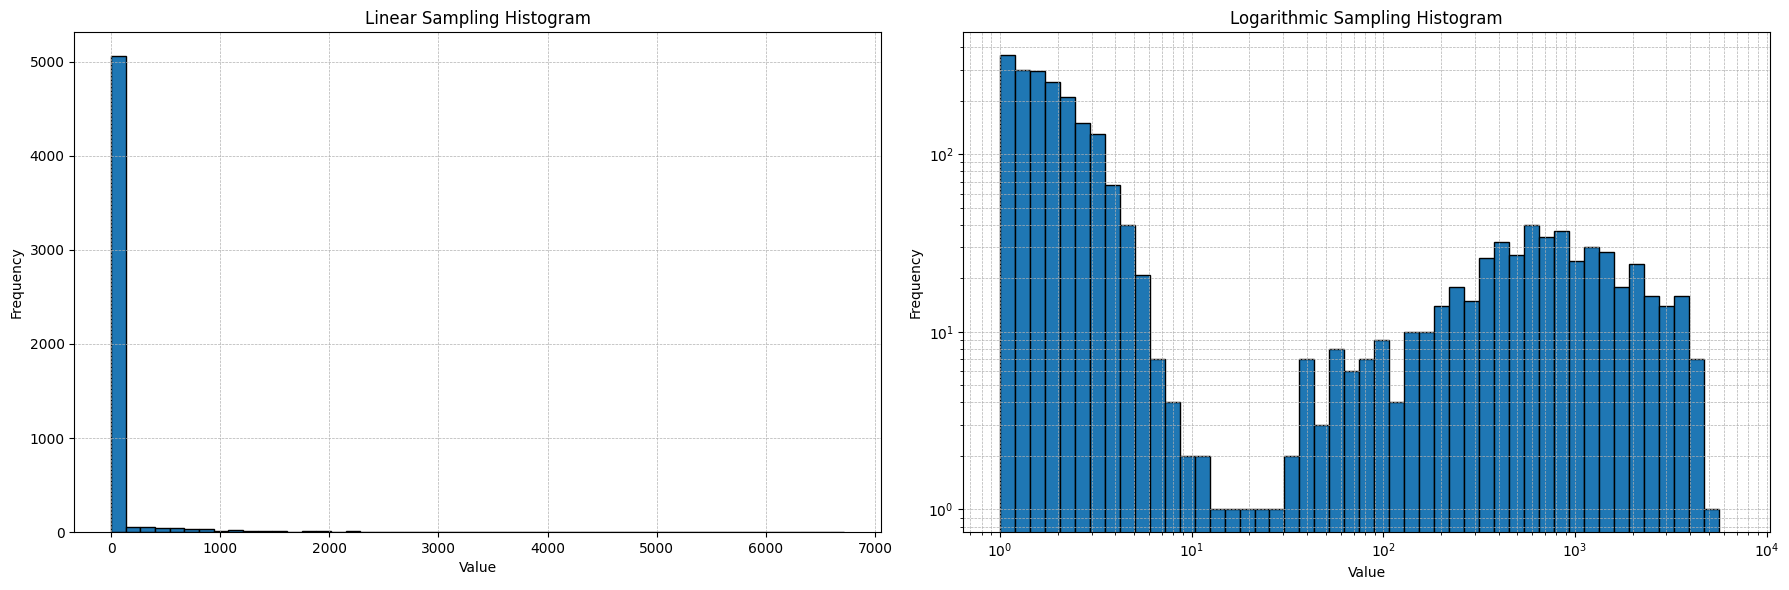

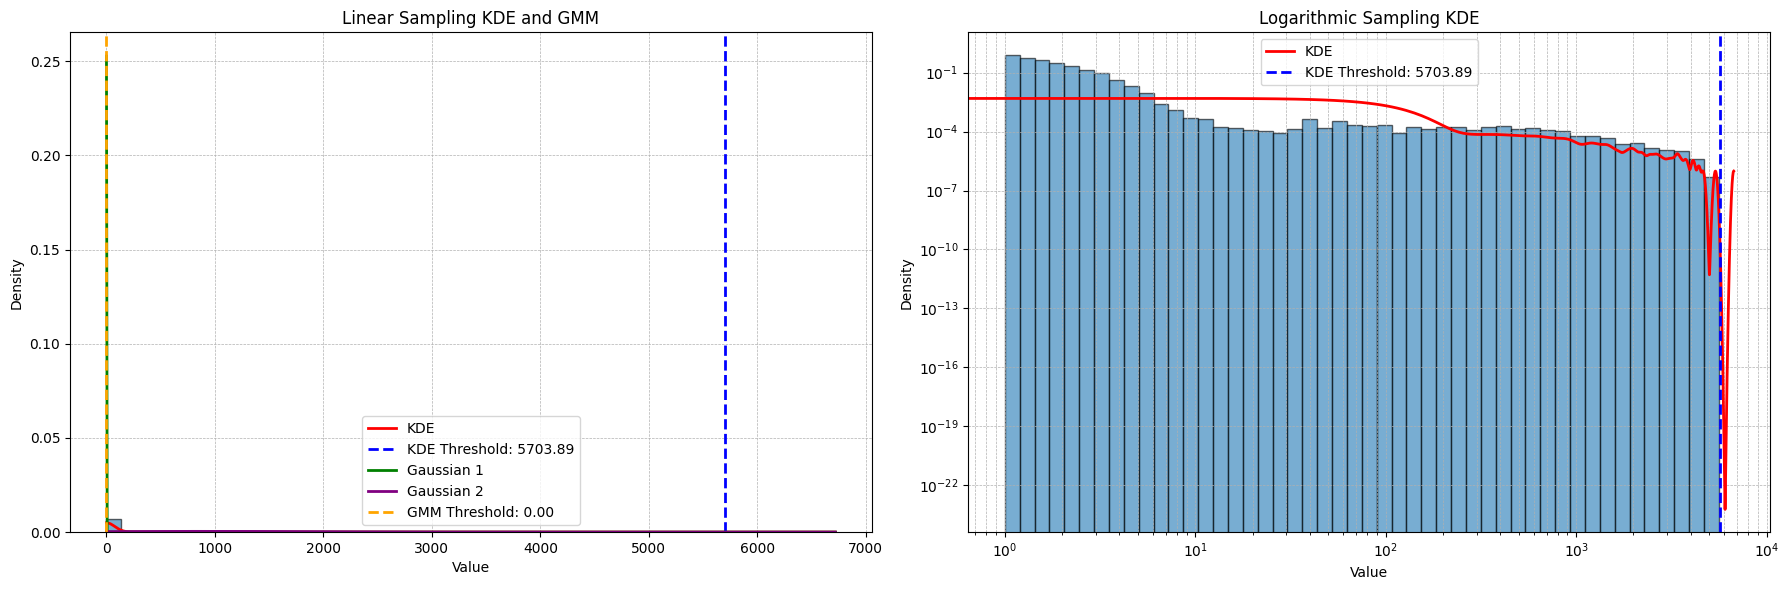

Threshold determined by KDE (Original Data): 5703.89
Threshold determined by GMM (Original Data): 0.00


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture

# Generate the bimodal dataset
np.random.seed(42)
low_intensity = np.random.exponential(scale=1, size=5000)
high_intensity = np.random.exponential(scale=1000, size=500)
data = np.concatenate([low_intensity, high_intensity])

# Plotting
plt.figure(figsize=(18, 6))

# Linear Sampling Histogram
plt.subplot(1, 2, 1)
plt.hist(data, bins=50, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Linear Sampling Histogram')
plt.grid(True, linestyle='--', linewidth=0.5)

# Logarithmic Sampling Histogram
bins_log = np.logspace(0, np.log10(data.max()), 50)  # Logarithmic bin edges
plt.subplot(1, 2, 2)
plt.hist(data, bins=bins_log, edgecolor='black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Logarithmic Sampling Histogram')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# KDE on Original Data
kde = gaussian_kde(data)
x = np.linspace(0, data.max(), 1000)
kde_values = kde(x)
# Find a non-zero minimum
nonzero_indices = kde_values > 1e-10
significant_x = x[nonzero_indices]
significant_kde_values = kde_values[nonzero_indices]
local_min_index = np.argmin(significant_kde_values)
threshold_kde = significant_x[local_min_index]

# GMM on Original Data
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(data.reshape(-1, 1))
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_).flatten()

# Finding intersection point of the two Gaussians
def gaussian(x, mean, std):
    return (1/(std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

x_dense = np.linspace(0, data.max(), 1000)
gaussian_1 = gaussian(x_dense, means[0], stds[0])
gaussian_2 = gaussian(x_dense, means[1], stds[1])
intersection_index = np.argwhere(np.diff(np.sign(gaussian_1 - gaussian_2))).flatten()
threshold_gmm = x_dense[intersection_index][0]

# Plotting KDE and GMM results
plt.figure(figsize=(18, 6))

# Linear Sampling KDE and GMM
plt.subplot(1, 2, 1)
plt.hist(data, bins=50, density=True, edgecolor='black', alpha=0.6)
plt.plot(x, kde_values, color='red', lw=2, label='KDE')
plt.axvline(threshold_kde, color='blue', linestyle='--', lw=2, label=f'KDE Threshold: {threshold_kde:.2f}')
plt.plot(x_dense, gaussian_1, color='green', lw=2, label='Gaussian 1')
plt.plot(x_dense, gaussian_2, color='purple', lw=2, label='Gaussian 2')
plt.axvline(threshold_gmm, color='orange', linestyle='--', lw=2, label=f'GMM Threshold: {threshold_gmm:.2f}')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Linear Sampling KDE and GMM')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)

# Logarithmic Sampling KDE
plt.subplot(1, 2, 2)
plt.hist(data, bins=bins_log, density=True, edgecolor='black', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.plot(x, kde_values, color='red', lw=2, label='KDE')
plt.axvline(threshold_kde, color='blue', linestyle='--', lw=2, label=f'KDE Threshold: {threshold_kde:.2f}')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Logarithmic Sampling KDE')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"Threshold determined by KDE (Original Data): {threshold_kde:.2f}")
print(f"Threshold determined by GMM (Original Data): {threshold_gmm:.2f}")
